# Q2 – Classification: Handling Class Imbalance

We use the Credit Card Fraud dataset to compare how different resampling strategies handle a very imbalanced dataset (only ~0.17% fraud cases).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Load Data

Download from Kaggle: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud  
Place `creditcard.csv` in the same folder as this notebook.

In [2]:
df = pd.read_csv('creditcard.csv')
print(f"Shape: {df.shape}")
print(f"Fraud ratio: {df['Class'].mean()*100:.3f}%")
df['Class'].value_counts()

Shape: (284807, 31)
Fraud ratio: 0.173%


Class
0    284315
1       492
Name: count, dtype: int64

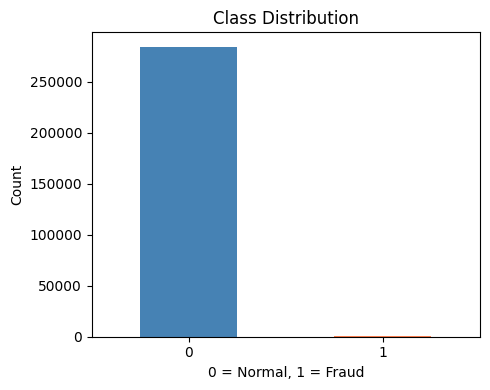

In [3]:
plt.figure(figsize=(5, 4))
df['Class'].value_counts().plot(kind='bar', color=['steelblue', 'coral'])
plt.title('Class Distribution')
plt.xlabel('0 = Normal, 1 = Fraud')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('q2_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Preprocessing

- V1–V28 are already PCA-transformed, so we leave them alone
- `Amount` is very skewed (most transactions are small but some are huge) → log transform
- `Time` is in seconds from the first transaction → we convert it to hour of day, which is more meaningful for detecting fraud patterns

In [4]:
df_clean = df.copy()

df_clean['Amount'] = np.log1p(df_clean['Amount'])
df_clean['Time']   = (df_clean['Time'] / 3600) % 24

scaler = StandardScaler()
df_clean[['Amount', 'Time']] = scaler.fit_transform(df_clean[['Amount', 'Time']])

X = df_clean.drop('Class', axis=1)
y = df_clean['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {X_train.shape[0]}  |  Test: {X_test.shape[0]}")
print(f"Fraud in train: {y_train.mean()*100:.3f}%")

Train: 227845  |  Test: 56962
Fraud in train: 0.173%


## 3. Train and Evaluate (helper function)

In [5]:
def train_and_evaluate(X_tr, y_tr, X_te, y_te, label=""):
    clfs = {
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
        'XGBoost':             XGBClassifier(n_estimators=100, random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0)
    }

    results, trained = [], {}
    for name, clf in clfs.items():
        clf.fit(X_tr, y_tr)
        y_pred = clf.predict(X_te)
        y_prob = clf.predict_proba(X_te)[:, 1]

        report  = classification_report(y_te, y_pred, output_dict=True)
        roc_auc = roc_auc_score(y_te, y_prob)

        results.append({
            'Model':             f"{name} {label}",
            'Precision (Fraud)': report['1']['precision'],
            'Recall (Fraud)':    report['1']['recall'],
            'F1 (Fraud)':        report['1']['f1-score'],
            'ROC-AUC':           roc_auc
        })
        trained[name] = (clf, y_pred, y_prob)

        print(f"\n{name} {label}")
        print(classification_report(y_te, y_pred, target_names=['Normal', 'Fraud']))
        print(f"ROC-AUC: {roc_auc:.4f}")

    return results, trained

## 4. Without Resampling

In [6]:
print("--- No Resampling ---")
results_orig, models_orig = train_and_evaluate(X_train, y_train, X_test, y_test, "(Original)")

--- No Resampling ---

Logistic Regression (Original)
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.83      0.65      0.73        98

    accuracy                           1.00     56962
   macro avg       0.92      0.83      0.87     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9589

Random Forest (Original)
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.94      0.82      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9581

XGBoost (Original)
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.89      0.79      0.83        98

    accuracy                           1.00     56

## 5. Confusion Matrices

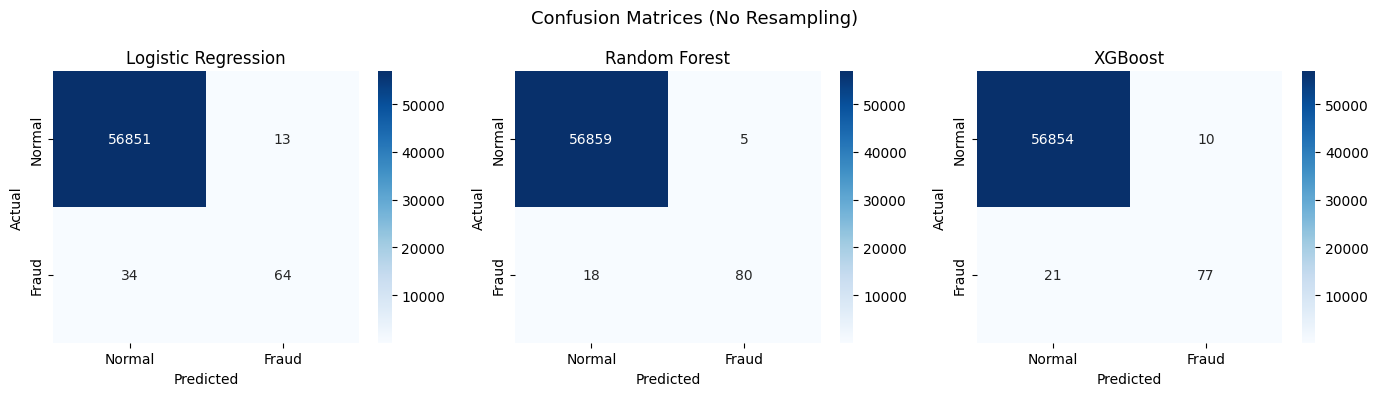

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, (name, (clf, y_pred, _)) in enumerate(models_orig.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
    axes[i].set_title(name)
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')
plt.suptitle('Confusion Matrices (No Resampling)', fontsize=13)
plt.tight_layout()
plt.savefig('q2_confusion_original.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. SMOTE (Oversampling)

SMOTE creates new synthetic fraud samples so that both classes are balanced during training. We only apply it to the training set — the test set stays untouched.

In [8]:
smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print("After SMOTE:")
print(pd.Series(y_train_smote).value_counts())

print("\n--- SMOTE ---")
results_smote, models_smote = train_and_evaluate(X_train_smote, y_train_smote, X_test, y_test, "(SMOTE)")

After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64

--- SMOTE ---

Logistic Regression (SMOTE)
              precision    recall  f1-score   support

      Normal       1.00      0.97      0.99     56864
       Fraud       0.05      0.92      0.10        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.54     56962
weighted avg       1.00      0.97      0.98     56962

ROC-AUC: 0.9695

Random Forest (SMOTE)
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.86      0.82      0.84        98

    accuracy                           1.00     56962
   macro avg       0.93      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9716

XGBoost (SMOTE)
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.71      0.85      0.77        9

## 7. Random Undersampling

Undersampling removes majority class samples until both classes are equal. It's faster and more aggressive than SMOTE but throws away a lot of data.

In [9]:
under = RandomUnderSampler(random_state=RANDOM_STATE)
X_train_under, y_train_under = under.fit_resample(X_train, y_train)
print("After Undersampling:")
print(pd.Series(y_train_under).value_counts())

print("\n--- Undersampling ---")
results_under, models_under = train_and_evaluate(X_train_under, y_train_under, X_test, y_test, "(Undersample)")

After Undersampling:
Class
0    394
1    394
Name: count, dtype: int64

--- Undersampling ---

Logistic Regression (Undersample)
              precision    recall  f1-score   support

      Normal       1.00      0.96      0.98     56864
       Fraud       0.04      0.92      0.07        98

    accuracy                           0.96     56962
   macro avg       0.52      0.94      0.52     56962
weighted avg       1.00      0.96      0.98     56962

ROC-AUC: 0.9764

Random Forest (Undersample)
              precision    recall  f1-score   support

      Normal       1.00      0.96      0.98     56864
       Fraud       0.04      0.90      0.08        98

    accuracy                           0.96     56962
   macro avg       0.52      0.93      0.53     56962
weighted avg       1.00      0.96      0.98     56962

ROC-AUC: 0.9759

XGBoost (Undersample)
              precision    recall  f1-score   support

      Normal       1.00      0.96      0.98     56864
       Fraud       0.03 

## 8. Comparison Table

In [10]:
all_results = pd.DataFrame(results_orig + results_smote + results_under)
all_results.round(4)

,Model,Precision (Fraud),Recall (Fraud),F1 (Fraud),ROC-AUC
0,Logistic Regression (Original),0.8312,0.6531,0.7314,0.9589
1,Random Forest (Original),0.9412,0.8163,0.8743,0.9581
2,XGBoost (Original),0.8851,0.7857,0.8324,0.9319
3,Logistic Regression (SMOTE),0.0541,0.9184,0.1022,0.9695
4,Random Forest (SMOTE),0.8602,0.8163,0.8377,0.9716
5,XGBoost (SMOTE),0.7094,0.8469,0.7721,0.9817
6,Logistic Regression (Undersample),0.0366,0.9184,0.0703,0.9764
7,Random Forest (Undersample),0.0412,0.8980,0.0787,0.9759
8,XGBoost (Undersample),0.0341,0.9082,0.0658,0.9746


## 9. ROC Curves

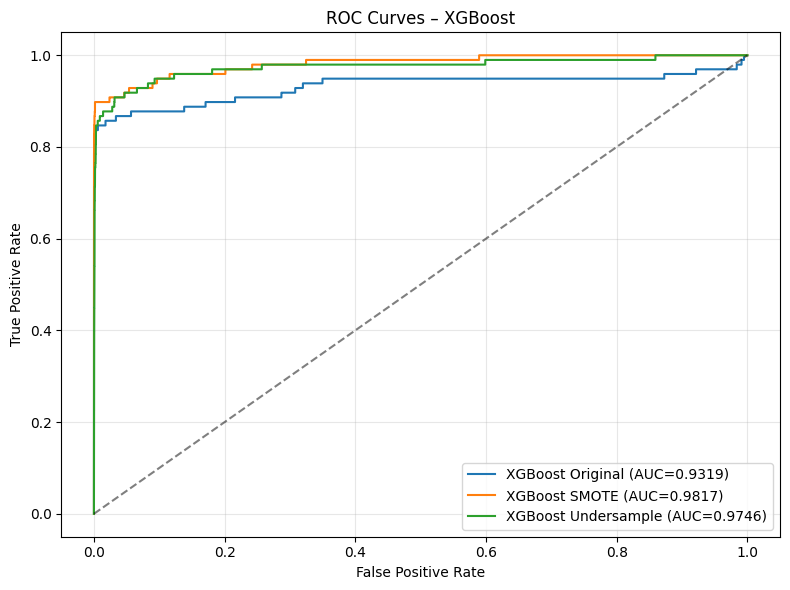

In [11]:
plt.figure(figsize=(8, 6))
for label, models_dict in [('Original', models_orig), ('SMOTE', models_smote), ('Undersample', models_under)]:
    _, _, y_prob = models_dict['XGBoost']
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'XGBoost {label} (AUC={auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves – XGBoost')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('q2_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Discussion

**Which error is worse in fraud detection?**
- Missing a fraud (False Negative): the bank loses money and the customer is hurt — this is costly
- Flagging a normal transaction as fraud (False Positive): the customer is annoyed but it's easy to fix — less costly

So we care more about **Recall** (catching fraud) than Precision.

**What did resampling do?**
1. Without resampling, models mostly predict "Normal" and miss a lot of fraud — high precision, low recall
2. SMOTE improved recall significantly while keeping precision reasonable
3. Undersampling improved recall even more but precision dropped more than SMOTE
4. XGBoost was the best model across all strategies